In [47]:
import os

print(os.getcwd())
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)


C:\Users\Acer\chronic\Chronic_Diseases


In [48]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Number of samples
n_samples = 1000

# Generate random demographic and health data
age = np.random.randint(30, 80, n_samples)
gender = np.random.choice(['Male', 'Female'], n_samples)
income = np.random.randint(20000, 100000, n_samples)
bmi = np.random.uniform(18.5, 40, n_samples)
smoking = np.random.choice(['Yes', 'No'], n_samples)
physical_activity = np.random.choice(['Low', 'Moderate', 'High'], n_samples)
hypertension = np.random.choice(['Yes', 'No'], n_samples)
cholesterol = np.random.uniform(150, 300, n_samples)

# Generate random chronic disease outcome
# Here we assume a simplified relationship between variables
def generate_chronic_disease(age, bmi, smoking, physical_activity, hypertension, cholesterol):
    risk = (age * 0.2) + (bmi * 0.3) + (cholesterol * 0.1)
    if smoking == 'Yes':
        risk += 20
    if physical_activity == 'Low':
        risk += 15
    elif physical_activity == 'Moderate':
        risk += 5
    else:
        risk -= 10
    if hypertension == 'Yes':
        risk += 25
    return 1 if risk > 50 else 0

chronic_disease = [generate_chronic_disease(age[i], bmi[i], smoking[i], physical_activity[i], hypertension[i], cholesterol[i]) for i in range(n_samples)]

# Create a DataFrame
df = pd.DataFrame({
    'Age': age,
    'Gender': gender,
    'Income': income,
    'BMI': bmi,
    'Smoking': smoking,
    'Physical_Activity': physical_activity,
    'Hypertension': hypertension,
    'Cholesterol': cholesterol,
    'Chronic_Disease': chronic_disease
})

# Save the synthetic dataset to a CSV file
df.to_csv('synthetic_chronic_diseases.csv', index=False)

# Display the first few rows of the dataset
df.head()


,Age,Gender,Income,BMI,Smoking,Physical_Activity,Hypertension,Cholesterol,Chronic_Disease
0,68,Male,97236,19.731525,No,Low,Yes,160.637394,1
1,58,Male,56509,23.342310,No,High,Yes,202.469409,1
2,44,Male,62534,21.324012,No,Moderate,Yes,279.374476,1
3,72,Female,38787,27.074975,Yes,Moderate,No,184.960922,1
4,37,Male,68845,38.336396,Yes,High,Yes,254.278120,1


In [49]:
df = pd.read_csv('synthetic_chronic_diseases.csv')
df.head()


,Age,Gender,Income,BMI,Smoking,Physical_Activity,Hypertension,Cholesterol,Chronic_Disease
0,68,Male,97236,19.731525,No,Low,Yes,160.637394,1
1,58,Male,56509,23.342310,No,High,Yes,202.469409,1
2,44,Male,62534,21.324012,No,Moderate,Yes,279.374476,1
3,72,Female,38787,27.074975,Yes,Moderate,No,184.960922,1
4,37,Male,68845,38.336396,Yes,High,Yes,254.278120,1


In [50]:
print(df.info())
print(df.describe())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1000 non-null   int64  
 1   Gender             1000 non-null   object 
 2   Income             1000 non-null   int64  
 3   BMI                1000 non-null   float64
 4   Smoking            1000 non-null   object 
 5   Physical_Activity  1000 non-null   object 
 6   Hypertension       1000 non-null   object 
 7   Cholesterol        1000 non-null   float64
 8   Chronic_Disease    1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB
None
               Age        Income          BMI  Cholesterol  Chronic_Disease
count  1000.000000   1000.000000  1000.000000  1000.000000      1000.000000
mean     54.830000  60297.562000    29.302033   224.643140         0.810000
std      14.346809  22657.577103     6.261822    42.813148         0.39

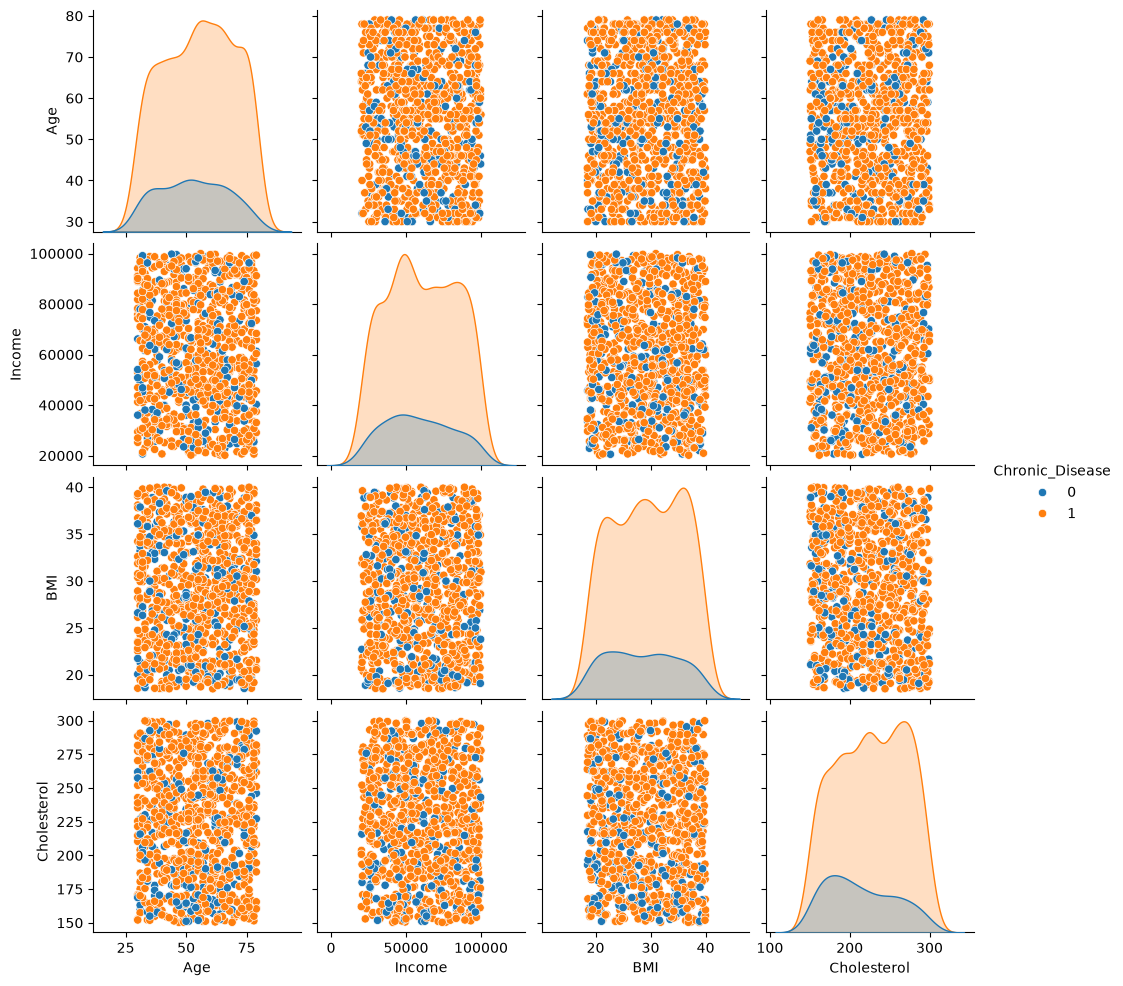

In [51]:
sns.pairplot(df, hue='Chronic_Disease')
plt.show()


In [52]:
df.ffill(inplace=True)


In [53]:
# ---------------- Feature Engineering ----------------
# Created BMI categories and Age groups from continuous features
# to provide clinically meaningful representations for the models.

# Create BMI Category
df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

# Create Age Group
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 40, 60, 100],
    labels=["Young", "Middle_Aged", "Senior"]
)
print(df[["Age", "Age_Group", "BMI", "BMI_Category"]].head())

   Age    Age_Group        BMI BMI_Category
0   68       Senior  19.731525       Normal
1   58  Middle_Aged  23.342310       Normal
2   44  Middle_Aged  21.324012       Normal
3   72       Senior  27.074975   Overweight
4   37        Young  38.336396        Obese


In [54]:
df = pd.get_dummies(df, drop_first=True)


In [55]:
X = df.drop('Chronic_Disease', axis=1)
y = df['Chronic_Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [56]:
model = RandomForestClassifier()

model.fit(X_train, y_train)
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [57]:
# Random Forest Prediction
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

# Logistic Regression Prediction
lr_pred = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy:", lr_accuracy)

print(classification_report(y_test, lr_pred))


Random Forest Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.96      0.78      0.86        59
           1       0.95      0.99      0.97       241

    accuracy                           0.95       300
   macro avg       0.95      0.89      0.91       300
weighted avg       0.95      0.95      0.95       300

Logistic Regression Accuracy: 0.9733333333333334
              precision    recall  f1-score   support

           0       0.96      0.90      0.93        59
           1       0.98      0.99      0.98       241

    accuracy                           0.97       300
   macro avg       0.97      0.95      0.96       300
weighted avg       0.97      0.97      0.97       300



Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.96      0.78      0.86        59
           1       0.95      0.99      0.97       241

    accuracy                           0.95       300
   macro avg       0.95      0.89      0.91       300
weighted avg       0.95      0.95      0.95       300



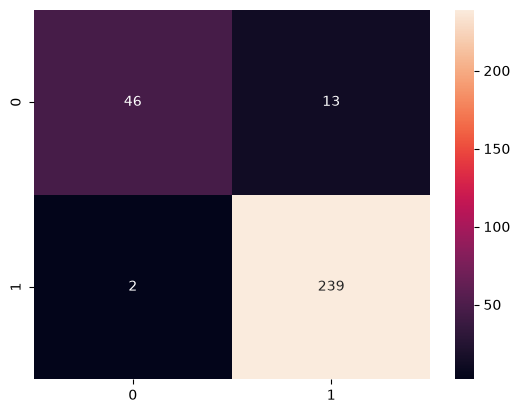

In [58]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()


In [59]:
lr_pred = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9733333333333334
              precision    recall  f1-score   support

           0       0.96      0.90      0.93        59
           1       0.98      0.99      0.98       241

    accuracy                           0.97       300
   macro avg       0.97      0.95      0.96       300
weighted avg       0.97      0.97      0.97       300



In [60]:
print("Random Forest Accuracy :", accuracy)
print("Logistic Regression Accuracy :", lr_accuracy)

Random Forest Accuracy : 0.95
Logistic Regression Accuracy : 0.9733333333333334


In [61]:
from sklearn.metrics import roc_auc_score

rf_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])

print("Random Forest AUC:", rf_auc)
print("Logistic Regression AUC:", lr_auc)

Random Forest AUC: 0.9877980167381674
Logistic Regression AUC: 0.9973978479499261


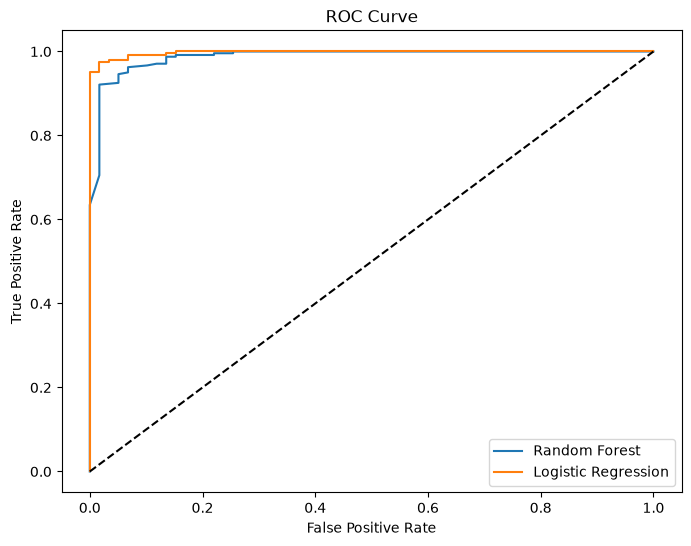

In [62]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

rf_fpr, rf_tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_model.predict_proba(X_test_scaled)[:,1])

plt.figure(figsize=(8,6))
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [63]:
from sklearn.metrics import f1_score

rf_f1 = f1_score(y_test, y_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("Random Forest F1-Score:", rf_f1)
print("Logistic Regression F1-Score:", lr_f1)

Random Forest F1-Score: 0.9695740365111561
Logistic Regression F1-Score: 0.9835390946502057


In [64]:
print("========== Model Evaluation ==========")

print(f"Random Forest Accuracy : {accuracy:.4f}")
print(f"Logistic Regression Accuracy : {lr_accuracy:.4f}")

print(f"Random Forest F1-Score : {rf_f1:.4f}")
print(f"Logistic Regression F1-Score : {lr_f1:.4f}")

print(f"Random Forest ROC-AUC : {rf_auc:.4f}")
print(f"Logistic Regression ROC-AUC : {lr_auc:.4f}")

if accuracy > lr_accuracy:
    print("\nBest Model: Random Forest")
else:
    print("\nBest Model: Logistic Regression")

========== Model Evaluation ==========
Random Forest Accuracy : 0.9500
Logistic Regression Accuracy : 0.9733
Random Forest F1-Score : 0.9696
Logistic Regression F1-Score : 0.9835
Random Forest ROC-AUC : 0.9878
Logistic Regression ROC-AUC : 0.9974

Best Model: Logistic Regression


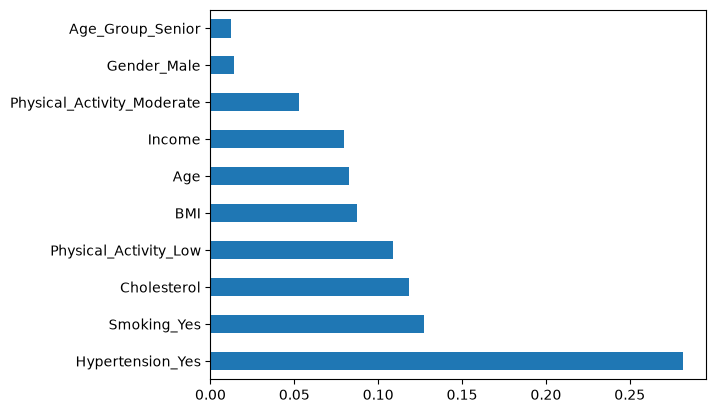

In [65]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.show()


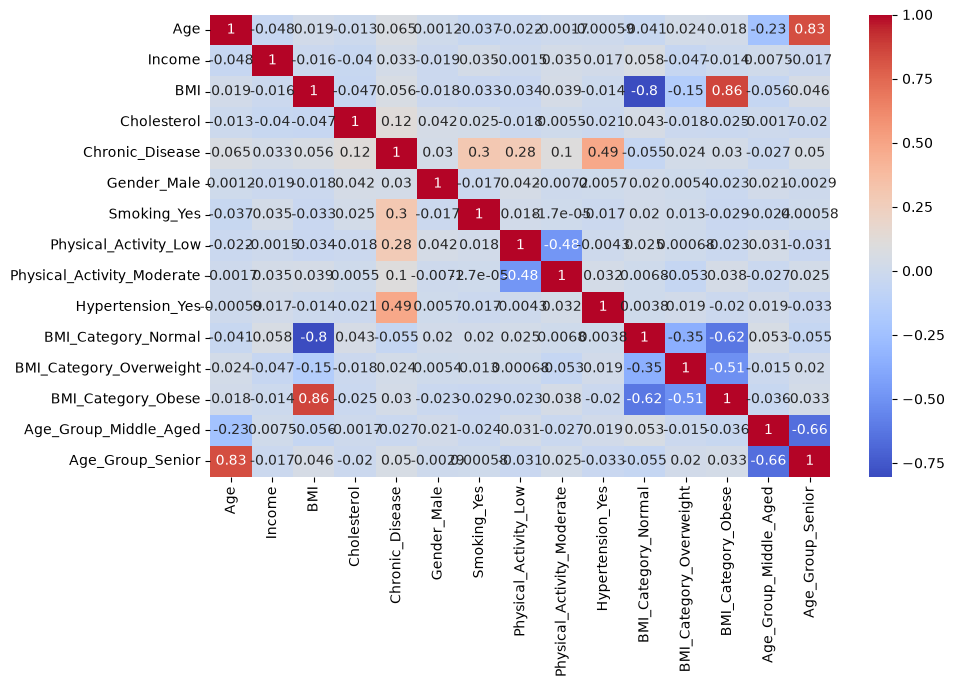

In [66]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()
